# LLM Classification


### Classification with LLM

## Notebook overview

This notebook uses an LLM through OpenRouter to classify product reviews as `CG` fake/computer-generated or `OR` original/human-written. It loads the dataset, creates prompts, calls the model for a sample of reviews, and evaluates the predictions with a classification report and confusion matrix.


In [103]:
# Import libraries for file paths, data handling, and table display
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from pqdm.threads import pqdm
import time
from openai import OpenAI
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

resources_dir = Path("../resources")
dataset_path = resources_dir / "fake reviews dataset.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print(f"Dataset path: {dataset_path}")

Dataset path: ../resources/fake reviews dataset.csv


In [2]:
if not dataset_path.exists():
    print("Dataset not found locally. Running downloader.py...")
    !python downloader.py

    if not dataset_path.exists():
        raise FileNotFoundError(f"Downloader finished, but dataset is still missing: {dataset_path}")

    print(f"Dataset downloaded to: {dataset_path}")
else:
    print(f"Dataset already present: {dataset_path}")

Dataset already present: ../resources/fake reviews dataset.csv


In [20]:
# Load the project helper module and split the dataset into train and test parts
import base

train_df, test_df = base.load_and_split_data_raw()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (32345, 5)
Test shape: (8087, 5)


In [21]:
display(train_df.head(13))
display(test_df.head())

,category,rating,label,text_,id
0,Kindle_Store_5,5.0,OR,I love paranormal books and this one made me feel so much!!! I was happy and mad and sad and then thrilled and then ...,25583
1,Books_5,4.0,CG,"Like almost all of James Patterson's books, the third is a boring, slow read.",29053
2,Clothing_Shoes_and_Jewelry_5,1.0,CG,Im very disappointed with my purchase. The quality is just not what I was expecting.Very pretty.I bought this for my,37975
3,Books_5,5.0,OR,Bought this book as a gift for my wife! Needless to say she loved it!,28705
4,Movies_and_TV_5,5.0,CG,"DVDs were what I expected. The quality of the video is very good, the music is very good, the DVD's are a must have ...",14166
5,Movies_and_TV_5,1.0,CG,I don't know what agenda this movie is being made. I saw it for the first time last night and I am very happy I did....,14485
6,Clothing_Shoes_and_Jewelry_5,5.0,OR,worked great for my dress to give me sleeves without dying of heat. Originally bought a large but was swimming in i...,38579
7,Clothing_Shoes_and_Jewelry_5,5.0,CG,Love this top. Makes nursing more comfortable and the materials are thick enough to make it comfortable.,37617
8,Clothing_Shoes_and_Jewelry_5,5.0,OR,I have had New Balance cross trainers before and am not disappointed.\nI walk 2 miles daily and they are very comfy....,38029
9,Books_5,3.0,CG,i think nothing can top this book. It is a history book that is well worth the time. I had to read it before going...,30583


,category,rating,label,text_,id
0,Toys_and_Games_5,1.0,OR,"Incredibly horrible quality and detail. Period. Seriously, it's nothing like the picture.",33060
1,Pet_Supplies_5,2.0,CG,"""MINIMAL"" Attractactant, IF ANY... (Cats are very picky",19899
2,Clothing_Shoes_and_Jewelry_5,5.0,OR,"Promptly delivers, no qualms about anything else.\n\nGreat boot, I wear it all the time now.\n\nIt works for the off...",38226
3,Books_5,5.0,CG,What can i say another word about the book? I really enjoyed this book! I am a big fan of the Harry Bosch,29582
4,Home_and_Kitchen_5,2.0,CG,Serious off-gassing!!! ugh! Not only do you have to clean the area around the,1080


In [22]:
! pwd

/Users/svetlana/Documents/CAS_ML/Text/Project/text_analysis/src


In [23]:
# Read the OpenRouter API key from a local file and create the API clien

with open("openrouter_api_key.txt", "r") as f:
    openrouter_api_key = f.read().strip()

print("Key starts with:", openrouter_api_key[:8])
print("Key length:", len(openrouter_api_key))

openai_client = OpenAI(
    api_key=openrouter_api_key,
    base_url="https://openrouter.ai/api/v1",
)

Key starts with: sk-or-v1
Key length: 73


In [24]:
# Select the LLM model used for review classification
MODEL_GPT4O = "openai/gpt-4o"
MODEL_GPT53 = "openai/gpt-5.3-chat"

In [25]:
system_prompt = """Classify sentiment!"""

In [26]:
def ask_llm(user_text, model_name = MODEL_GPT4O):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_text}
    ]

    response = openai_client.chat.completions.create(
        model=model_name,
        messages=messages,
        temperature=0
    )

    return response.choices[0].message.content

In [27]:
answer_4o = ask_llm("Nice weather", model_name=MODEL_GPT4O)
print(answer_4o)

Positive


In [28]:
answer_53 = ask_llm("Nice weather", model_name=MODEL_GPT53)
print(answer_53)

Positive


In [29]:
# Short system prompt: tells the LLM how to classify fake vs. original reviews
system_prompt = """
You are an expert fake-review detector.

Your task is to classify product reviews as either:

CG = computer-generated or fake review
OR = original human-written review

Use the review text, rating, and product category to decide.

Look for signs of CG/fake reviews such as:
- generic language with little specific detail
- repetitive or unnatural wording
- contradictions inside the review
- overly vague praise or criticism
- strange grammar or sentence structure
- review text that feels incomplete or copied
- mismatch between rating and review sentiment
- unrealistic emotional tone
- lack of concrete product experience

Look for signs of OR/real reviews such as:
- specific personal experience
- natural emotional reactions
- concrete details about the product
- realistic imperfections in writing
- clear connection between rating and opinion

Return only valid JSON in this exact format:

{
  "label": "CG or OR"
}

Do not write markdown.
Do not write anything outside the JSON.
"""

In [30]:
# Main system prompt: tells the LLM how to classify fake vs. original reviews
system_prompt_main = """
You are an expert fake-review detector.

Your task is to classify product reviews as either:

CG = computer-generated or fake review
OR = original human-written review

Use the review text, rating, and product category.

Important patterns from this dataset:

1. OR reviews often include specific personal experience.
Example:
Category: Kindle_Store_5
Rating: 5.0
Review: I love paranormal books and this one made me feel so much!!! I was happy and mad and sad and then thrilled and then ...
Label: OR
Reason: Emotional and personal reaction to reading the book.

2. CG reviews can be short, generic, or overly broad.
Example:
Category: Books_5
Rating: 4.0
Review: Like almost all of James Patterson's books, the third is a boring, slow read.
Label: CG
Reason: Generic statement with limited concrete detail.

3. CG reviews may contain unnatural or contradictory text.
Example:
Category: Clothing_Shoes_and_Jewelry_5
Rating: 1.0
Review: Im very disappointed with my purchase. The quality is just not what I was expecting.Very pretty.I bought this for my
Label: CG
Reason: The text is incomplete and contradictory.

4. OR reviews may be simple but still natural.
Example:
Category: Books_5
Rating: 5.0
Review: Bought this book as a gift for my wife! Needless to say she loved it!
Label: OR
Reason: Short but believable personal purchasing experience.

5. CG reviews may sound repetitive and promotional.
Example:
Category: Movies_and_TV_5
Rating: 5.0
Review: DVDs were what I expected. The quality of the video is very good, the music is very good, the DVD's are a must have ...
Label: CG
Reason: Repetitive praise and generic wording.

6. CG reviews may have sentiment/rating inconsistency.
Example:
Category: Movies_and_TV_5
Rating: 1.0
Review: I don't know what agenda this movie is being made. I saw it for the first time last night and I am very happy I did....
Label: CG
Reason: Negative rating conflicts with positive wording.

7. OR reviews often mention concrete usage details.
Example:
Category: Clothing_Shoes_and_Jewelry_5
Rating: 5.0
Review: worked great for my dress to give me sleeves without dying of heat. Originally bought a large but was swimming in i...
Label: OR
Reason: Specific use case and sizing detail.

8. CG reviews may sound smooth but generic.
Example:
Category: Clothing_Shoes_and_Jewelry_5
Rating: 5.0
Review: Love this top. Makes nursing more comfortable and the materials are thick enough to make it comfortable.
Label: CG
Reason: General praise with limited personal detail.

9. OR reviews often include real-life habits or repeated use.
Example:
Category: Clothing_Shoes_and_Jewelry_5
Rating: 5.0
Review: I have had New Balance cross trainers before and am not disappointed.
I walk 2 miles daily and they are very comfy....
Label: OR
Reason: Specific brand history and daily walking use.

10. CG reviews may contain vague praise that does not fit the rating well.
Example:
Category: Books_5
Rating: 3.0
Review: i think nothing can top this book. It is a history book that is well worth the time. I had to read it before going...
Label: CG
Reason: Strong praise does not match the medium rating.

11. CG reviews may repeat generic positive phrases without giving specific evidence.
Example:
Category: Books_5
Rating: 4.0
Review: I do like this book, and it's an interesting and good read. I would recommend it.I read this book in the middle of ...
Label: CG
Reason: The review uses broad praise like interesting, good read, and recommend it, but gives little concrete detail.

12. OR reviews can be very short when they contain a specific personal habit or use case.
Example:
Category: Electronics_5
Rating: 5.0
Review: Love my p-Touch - i label everything that doesn't move.
Label: OR
Reason: Short but natural, with a specific personal use habit.

Classification rules:
- Predict CG when the review is generic, repetitive, contradictory, incomplete, or inconsistent with the rating.
- Predict OR when the review contains a believable personal experience, concrete use case, specific product detail, or natural emotional reaction.
- Do not assume a review is OR only because it has grammar mistakes.
- Do not assume a review is CG only because it is short.
- Focus on the style and consistency of the review.

Return only valid JSON in this exact format:

{
  "label": "CG or OR"
}

Do not write markdown.
Do not write anything outside the JSON.
"""

In [119]:
def classify_review_json(category, rating, review_text, model_name, system_prompt_text=system_prompt_main, debug=False, max_retries=3):
    user_prompt = f"""
Category: {category}
Rating: {rating}
Review: {review_text}
"""

    messages = [
        {"role": "system", "content": system_prompt_text},
        {"role": "user", "content": user_prompt}
    ]
    last_error = None

    for attempt in range(max_retries + 1):
        try:
            if debug:
                print(f"Attempt {attempt + 1}/{max_retries + 1}")
                print(messages)

            response = openai_client.chat.completions.create(
                model=model_name,
                messages=messages,
                temperature=0
            )

            if debug:
                print(response)

            content = response.choices[0].message.content.strip()

            result = json.loads(content)

            if not isinstance(result, dict):
                raise ValueError(f"Result is not a JSON object: {result}")

            if "label" not in result:
                raise ValueError(f'Missing required field "label": {result}')

            if result["label"] not in ["CG", "OR"]:
                raise ValueError(f'Invalid label value: {result["label"]}')

            return result

        except Exception as e:
            last_error = e

            if debug:
                print(f"Attempt failed: {e}")

            if attempt < max_retries:
                time.sleep(3)
            else:
                return dict()


In [32]:
print(test_df.columns)

Index(['category', 'rating', 'label', 'text_', 'id'], dtype='str')


In [110]:
def classify_test_reviews(test_df, model_name,system_prompt_text=system_prompt_main, n=50, debug=False):
    test_50 = test_df.head(n).copy()
    rows = [row for _, row in test_50.iterrows()]
    
    results = pqdm(rows, lambda row: classify_review_json(
        category=row["category"],
        rating=row["rating"],
        review_text=row["text_"],
        model_name=model_name,
        system_prompt_text=system_prompt_text,
        debug=debug,
        ), n_jobs=20)

    results = pd.Series(results, index=test_50.index)

    # Safely extract predicted label
    def get_label_safe(x):
        if isinstance(x, dict):
            return x.get("label", None)
        return None

    # Safely extract explanation or error message
    def get_explanation_safe(x):
        if isinstance(x, dict):
            return x.get("explanation", "")
        return str(x)

    test_50["predicted_label"] = results.apply(get_label_safe)
    test_50["explanation"] = results.apply(get_explanation_safe)

    return test_50[
        ["category", "rating", "label", "predicted_label", "explanation", "text_", "id"]
    ]

In [62]:
##Use GPT-4o:
test_50_gpt4o = classify_test_reviews(
    test_df,
    model_name=MODEL_GPT4O,
    system_prompt_text=system_prompt,
    n=50
)


QUEUEING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/50 [00:00<?, ?it/s]

In [63]:
##Use GPT-4o main:
# Sample sizes we want to test
sample_sizes = [50, 100, 200, 500]

# Dictionary to store all results
results = {}

for N in sample_sizes:
    if N > len(test_df):
        raise ValueError(f"N={N}, but test_df has only {len(test_df)} rows")

    # Randomly select N rows from the full test_df
    test_df_random = test_df.sample(n=N, random_state=42)

    # Result name: test_50_gpt4o, test_200_gpt4o, test_500_gpt4o
    result_name = f"test_{N}_gpt4o"

    # Run classification and save the result
    results[result_name] = classify_test_reviews(
        test_df_random,
        model_name=MODEL_GPT4O,
        system_prompt_text=system_prompt_main,
        n=N
    )

QUEUEING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/50 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/100 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/100 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/200 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/200 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/500 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/500 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/500 [00:00<?, ?it/s]

In [66]:
##Use GPT-5.3 with main promt:
N = 500

# Randomly select 500 rows from the full test_df
test_df_random_500 = test_df.sample(n=N, random_state=42)

# Run classification
test_500_gpt53_main = classify_test_reviews(
    test_df_random_500,
    model_name=MODEL_GPT53,
    system_prompt_text=system_prompt_main,
    n=N
)

QUEUEING TASKS | :   0%|          | 0/500 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/500 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/500 [00:00<?, ?it/s]

In [96]:
from sklearn.metrics import classification_report

def print_classification_results(result_df):
    # True labels from dataset
    y_true = result_df["label"]

    # Predicted labels from selected LLM model
    y_pred = result_df["predicted_label"]

    # Print precision, recall, and F1 score
    print(classification_report(
        y_true,
        y_pred,
        labels=["CG", "OR"]
    ))

In [53]:
# Print a full classification report
# This shows precision, recall, and F1 score for both CG and OR
print_classification_results(test_50_gpt4o)

              precision    recall  f1-score   support

          CG       0.93      0.70      0.80        20
          OR       0.83      0.97      0.89        30

    accuracy                           0.86        50
   macro avg       0.88      0.83      0.85        50
weighted avg       0.87      0.86      0.86        50



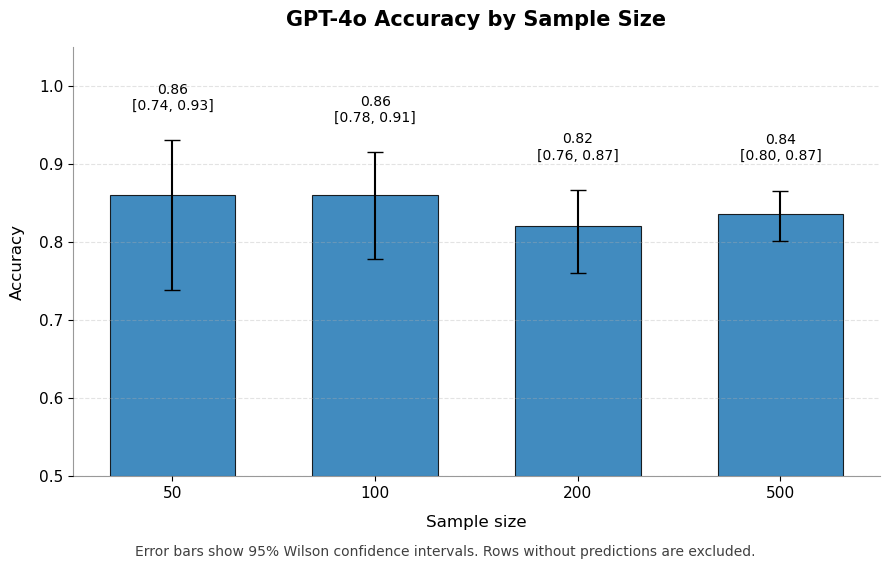

N=50: accuracy=0.860, 95% CI=[0.738, 0.930], valid n=50
N=100: accuracy=0.860, 95% CI=[0.779, 0.915], valid n=100
N=200: accuracy=0.820, 95% CI=[0.761, 0.867], valid n=200
N=500: accuracy=0.836, 95% CI=[0.801, 0.866], valid n=500


In [81]:
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# Calculate accuracy and 95% confidence intervals for each sample size
accuracies = {}
ci_lowers = {}
ci_uppers = {}
n_valids = {}

# alpha=0.05 means a 95% confidence interval
alpha = 0.05

for N in sample_sizes:
    result_name = f"test_{N}_gpt4o"
    df = results[result_name]

    # Keep only rows where prediction exists
    df_valid = df.dropna(subset=["predicted_label"])

    # Number of valid predictions
    n_valid = len(df_valid)

    # Handle the case where there are no valid predictions
    if n_valid == 0:
        accuracies[N] = float("nan")
        ci_lowers[N] = float("nan")
        ci_uppers[N] = float("nan")
        n_valids[N] = 0
        continue

    # Count correct predictions
    n_correct = (df_valid["label"] == df_valid["predicted_label"]).sum()

    # Calculate accuracy
    accuracy = n_correct / n_valid

    # Calculate Wilson confidence interval for accuracy
    ci_low, ci_high = proportion_confint(
        count=n_correct,
        nobs=n_valid,
        alpha=alpha,
        method="wilson"
    )

    # Store results
    accuracies[N] = accuracy
    ci_lowers[N] = ci_low
    ci_uppers[N] = ci_high
    n_valids[N] = n_valid


# Prepare data for plotting
x_labels = [str(N) for N in accuracies.keys()]
y_values = list(accuracies.values())

# Error bars in matplotlib require distances from the estimate
# to the lower and upper confidence interval bounds
yerr_lower = [
    accuracies[N] - ci_lowers[N]
    for N in accuracies.keys()
]

yerr_upper = [
    ci_uppers[N] - accuracies[N]
    for N in accuracies.keys()
]

yerr = [yerr_lower, yerr_upper]


# Create a modern-looking plot
plt.figure(figsize=(9, 5.5))

bars = plt.bar(
    x_labels,
    y_values,
    yerr=yerr,
    capsize=6,
    width=0.62,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

# Title and labels
plt.title(
    "GPT-4o Accuracy by Sample Size",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sample size", fontsize=12, labelpad=10)
plt.ylabel("Accuracy", fontsize=12, labelpad=10)

# Y-axis limits
plt.ylim(0.5, 1.05)

# Add a subtle horizontal grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# Remove top and right borders for a cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Make remaining borders softer
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)

# Make ticks cleaner
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add accuracy and confidence interval labels above bars
for bar, N in zip(bars, accuracies.keys()):
    height = bar.get_height()

    ci_low = ci_lowers[N]
    ci_high = ci_uppers[N]

    label = f"{height:.2f}\n[{ci_low:.2f}, {ci_high:.2f}]"

    text_y = min(ci_high + 0.035, 1.03)

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        text_y,
        label,
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add explanatory note
plt.figtext(
    0.5,
    -0.02,
    "Error bars show 95% Wilson confidence intervals. Rows without predictions are excluded.",
    ha="center",
    fontsize=10,
    alpha=0.75
)

plt.tight_layout()
plt.show()


# Print exact values
for N in accuracies.keys():
    print(
        f"N={N}: "
        f"accuracy={accuracies[N]:.3f}, "
        f"95% CI=[{ci_lowers[N]:.3f}, {ci_uppers[N]:.3f}], "
        f"valid n={n_valids[N]}"
    )

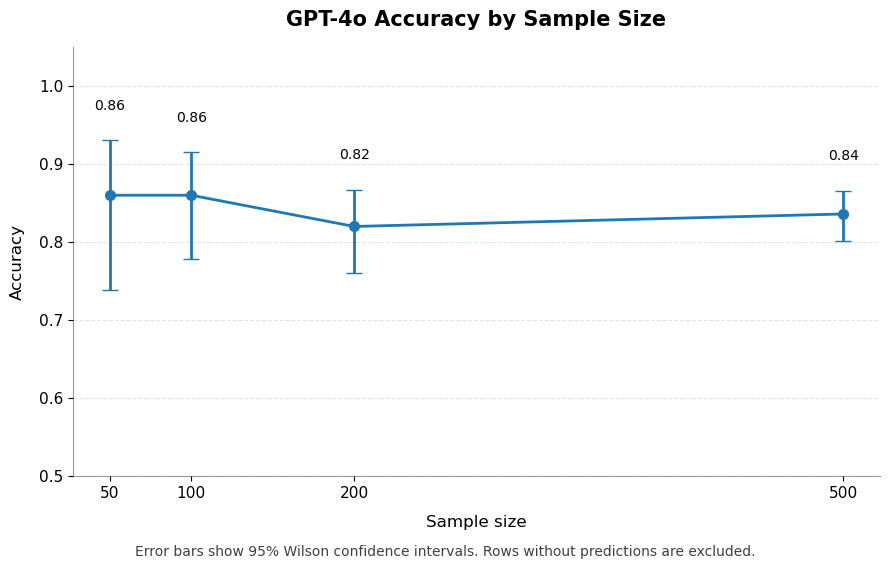

N=50: accuracy=0.860, 95% CI=[0.738, 0.930], valid n=50
N=100: accuracy=0.860, 95% CI=[0.779, 0.915], valid n=100
N=200: accuracy=0.820, 95% CI=[0.761, 0.867], valid n=200
N=500: accuracy=0.836, 95% CI=[0.801, 0.866], valid n=500


In [80]:
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# Calculate accuracy and 95% confidence intervals for each sample size
accuracies = {}
ci_lowers = {}
ci_uppers = {}
n_valids = {}

alpha = 0.05

for N in sample_sizes:
    result_name = f"test_{N}_gpt4o"
    df = results[result_name]

    # Keep only rows where prediction exists
    df_valid = df.dropna(subset=["predicted_label"])

    n_valid = len(df_valid)

    if n_valid == 0:
        accuracies[N] = float("nan")
        ci_lowers[N] = float("nan")
        ci_uppers[N] = float("nan")
        n_valids[N] = 0
        continue

    n_correct = (df_valid["label"] == df_valid["predicted_label"]).sum()
    accuracy = n_correct / n_valid

    ci_low, ci_high = proportion_confint(
        count=n_correct,
        nobs=n_valid,
        alpha=alpha,
        method="wilson"
    )

    accuracies[N] = accuracy
    ci_lowers[N] = ci_low
    ci_uppers[N] = ci_high
    n_valids[N] = n_valid


# Sort by sample size, useful for line plots
sample_sizes_sorted = sorted(accuracies.keys())

x_values = sample_sizes_sorted
y_values = [accuracies[N] for N in sample_sizes_sorted]

yerr_lower = [
    accuracies[N] - ci_lowers[N]
    for N in sample_sizes_sorted
]

yerr_upper = [
    ci_uppers[N] - accuracies[N]
    for N in sample_sizes_sorted
]

yerr = [yerr_lower, yerr_upper]


# Create modern line plot with confidence intervals
plt.figure(figsize=(9, 5.5))

plt.errorbar(
    x_values,
    y_values,
    yerr=yerr,
    fmt="o-",
    capsize=6,
    linewidth=2,
    markersize=7
)

plt.title(
    "GPT-4o Accuracy by Sample Size",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sample size", fontsize=12, labelpad=10)
plt.ylabel("Accuracy", fontsize=12, labelpad=10)

plt.ylim(0.5, 1.05)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)

plt.xticks(sample_sizes_sorted, fontsize=11)
plt.yticks(fontsize=11)

# Add value labels near points
for N in sample_sizes_sorted:
    accuracy = accuracies[N]
    ci_high = ci_uppers[N]

    plt.text(
        N,
        min(ci_high + 0.035, 1.03),
        f"{accuracy:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.figtext(
    0.5,
    -0.02,
    "Error bars show 95% Wilson confidence intervals. Rows without predictions are excluded.",
    ha="center",
    fontsize=10,
    alpha=0.75
)

plt.tight_layout()
plt.show()


# Print exact values
for N in sample_sizes_sorted:
    print(
        f"N={N}: "
        f"accuracy={accuracies[N]:.3f}, "
        f"95% CI=[{ci_lowers[N]:.3f}, {ci_uppers[N]:.3f}], "
        f"valid n={n_valids[N]}"
    )

In [69]:
test_50_gpt4o = results["test_50_gpt4o"]
test_100_gpt4o = results["test_100_gpt4o"]
test_200_gpt4o = results["test_200_gpt4o"]
test_500_gpt4o = results["test_500_gpt4o"]

In [71]:
print_classification_results(test_500_gpt4o)

              precision    recall  f1-score   support

          CG       0.87      0.80      0.83       259
          OR       0.80      0.88      0.84       241

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



In [67]:
print_classification_results(test_500_gpt53_main )

              precision    recall  f1-score   support

          CG       0.83      0.86      0.84       259
          OR       0.84      0.81      0.82       241

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



In [75]:
# Create a confusion matrix
# Use only valid predictions
df_valid = test_500_gpt4o.dropna(subset=["predicted_label"])

y_true = df_valid["label"]
y_pred = df_valid["predicted_label"]

# Create a confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=["CG", "OR"])

# Convert confusion matrix into a readable table
cm_df = pd.DataFrame(
    cm,
    index=["True CG", "True OR"],
    columns=["Predicted CG", "Predicted OR"]
)

# Display the confusion matrix table
cm_df

,Predicted CG,Predicted OR
True CG,207,52
True OR,30,211


In [76]:
# Export LLM prediction results to CSV
df_valid = test_500_gpt4o.dropna(subset=["predicted_label"]).copy()

# Correct predictions
correct_predictions = df_valid[df_valid["label"] == df_valid["predicted_label"]]

# Wrong predictions
wrong_predictions = df_valid[df_valid["label"] != df_valid["predicted_label"]]

# Save to CSV files
correct_predictions.to_csv("correct_predictions_llm.csv", index=False, encoding="utf-8-sig")
wrong_predictions.to_csv("wrong_predictions_llm.csv", index=False, encoding="utf-8-sig")

print("Correct predictions:", len(correct_predictions))
print("Wrong predictions:", len(wrong_predictions))

Correct predictions: 418
Wrong predictions: 82


In [82]:
# 10 random wrong predictions
import pandas as pd

# Load wrong predictions file
wrong_df = pd.read_csv("wrong_predictions_llm.csv")

# Take 10 random wrong predictions
wrong_10 = wrong_df.sample(n=10, random_state=42)

# Display selected examples
wrong_10[["category", "rating", "label", "predicted_label", "text_"]]

,category,rating,label,predicted_label,text_
30,Pet_Supplies_5,5.0,CG,OR,This double bowl set is perfect for the size and quality of this product. I have one cat and two small dogs and I a...
0,Sports_and_Outdoors_5,5.0,CG,OR,I use these to count the number of pieces of clothing I have left for my family.
22,Electronics_5,4.0,CG,OR,When I first got the mic it was a little bit too loud. When I got the mic it sounded so much better than the ones I ...
31,Clothing_Shoes_and_Jewelry_5,4.0,CG,OR,Super cute and exactly like the picture. It is a little snug but not too tight.
18,Kindle_Store_5,5.0,CG,OR,I love the Toni Diamond series. The characters are well developed and the story is well told.
28,Home_and_Kitchen_5,5.0,CG,OR,"Beautiful bed!\nOnly wished the headboard was a little wider, which is a nice bonus"
10,Sports_and_Outdoors_5,5.0,OR,CG,"This product is made very well and at such a value, it does a lot if you are a fisher!"
53,Books_5,5.0,OR,CG,We are waiting for more. Great series. Fun to read with my girls. Love all of the stories. Wonderful work.
4,Clothing_Shoes_and_Jewelry_5,5.0,CG,OR,Purchase for a friend who is an avid tennis player. I will be purchasing more in other colors.
12,Tools_and_Home_Improvement_5,4.0,CG,OR,This tool does what its supposed to do. I've used it for a couple of years now and it's very well made. The only t...


In [90]:
# Create new system propmt
examples_text = ""

for number, (_, row) in enumerate(wrong_10.iterrows(), start=13):
    examples_text += f"""
{number}. Previous mistake: this review should be classified as {row["label"]}.
Example:
Category: {row["category"]}
Rating: {row["rating"]}
Review: {row["text_"]}
Label: {row["label"]}
Reason: The previous prediction was {row["predicted_label"]}, but the correct label is {row["label"]}.
"""
    
print(examples_text)


13. Previous mistake: this review should be classified as CG.
Example:
Category: Pet_Supplies_5
Rating: 5.0
Review: This double bowl set is perfect for the size and quality of this product.  I have one cat and two small dogs and I am using this for the first time in a long time.  It is still very sturdy and I am very pleased.I bought this for my dog who is a chewer
Label: CG
Reason: The previous prediction was OR, but the correct label is CG.

14. Previous mistake: this review should be classified as CG.
Example:
Category: Sports_and_Outdoors_5
Rating: 5.0
Review: I use these to count the number of pieces of clothing I have left for my family.
Label: CG
Reason: The previous prediction was OR, but the correct label is CG.

15. Previous mistake: this review should be classified as CG.
Example:
Category: Electronics_5
Rating: 4.0
Review: When I first got the mic it was a little bit too loud. When I got the mic it sounded so much better than the ones I got with the TRS-80. I was concerned

In [91]:
# Add these examples to your prompt
system_prompt_main_improved = system_prompt_main.replace(
    "Classification rules:",
    f"""
Additional examples from previous model mistakes:
{examples_text}

Classification rules:
"""
)
print(system_prompt_main_improved)


You are an expert fake-review detector.

Your task is to classify product reviews as either:

CG = computer-generated or fake review
OR = original human-written review

Use the review text, rating, and product category.

Important patterns from this dataset:

1. OR reviews often include specific personal experience.
Example:
Category: Kindle_Store_5
Rating: 5.0
Review: I love paranormal books and this one made me feel so much!!! I was happy and mad and sad and then thrilled and then ...
Label: OR
Reason: Emotional and personal reaction to reading the book.

2. CG reviews can be short, generic, or overly broad.
Example:
Category: Books_5
Rating: 4.0
Review: Like almost all of James Patterson's books, the third is a boring, slow read.
Label: CG
Reason: Generic statement with limited concrete detail.

3. CG reviews may contain unnatural or contradictory text.
Example:
Category: Clothing_Shoes_and_Jewelry_5
Rating: 1.0
Review: Im very disappointed with my purchase. The quality is just not

In [120]:
test_500_gpt4o_improved = classify_test_reviews(
    test_df_random_500,
    model_name=MODEL_GPT4O,
    system_prompt_text=system_prompt_main_improved,
    n=500,
)

QUEUEING TASKS | :   0%|          | 0/500 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/500 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/500 [00:00<?, ?it/s]

In [121]:
from sklearn.metrics import classification_report

def print_classification_results(result_df):
    # Make a clean copy
    df_valid = result_df.copy()

    # Convert labels to string and remove extra spaces
    df_valid["label"] = df_valid["label"].astype(str).str.strip()
    df_valid["predicted_label"] = df_valid["predicted_label"].astype(str).str.strip()

    # Keep only valid labels
    df_valid = df_valid[
        df_valid["label"].isin(["CG", "OR"]) &
        df_valid["predicted_label"].isin(["CG", "OR"])
    ].copy()

    # True labels from dataset
    y_true = df_valid["label"].to_numpy()

    # Predicted labels from selected LLM model
    y_pred = df_valid["predicted_label"].to_numpy()

    # Print precision, recall, and F1 score
    print(classification_report(
        y_true,
        y_pred,
        labels=["CG", "OR"],
        zero_division=0
    ))

In [122]:
print_classification_results(test_500_gpt4o_improved)

              precision    recall  f1-score   support

          CG       0.86      0.92      0.89       255
          OR       0.90      0.84      0.87       237

    accuracy                           0.88       492
   macro avg       0.88      0.88      0.88       492
weighted avg       0.88      0.88      0.88       492



In [123]:
# Export improved LLM prediction results to CSV
df_valid = test_500_gpt4o_improved.dropna(subset=["predicted_label"]).copy()

# Correct predictions
correct_predictions = df_valid[df_valid["label"] == df_valid["predicted_label"]]

# Wrong predictions
wrong_predictions = df_valid[df_valid["label"] != df_valid["predicted_label"]]

# Output folder: go one level up from src, then to generated/predictions
output_dir = "../generated/predictions"

# Create folder if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Save to CSV files
correct_predictions.to_csv(
    f"{output_dir}/correct_predictions_llm.csv",
    index=False,
    encoding="utf-8-sig"
)

wrong_predictions.to_csv(
    f"{output_dir}/wrong_predictions_llm.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved to:", os.path.abspath(output_dir))
print("Correct predictions:", len(correct_predictions))
print("Wrong predictions:", len(wrong_predictions))

Saved to: /Users/svetlana/Documents/CAS_ML/Text/Project/text_analysis/generated/predictions
Correct predictions: 433
Wrong predictions: 59


In [124]:
summary_table = pd.DataFrame({
    "Classifier": ["XGBoost", "Random Forest", "LLM"],
    "Precision": [0.92, 0.89, 0.88],
    "Recall": [0.92, 0.89, 0.88],
    "F1-score": [0.92, 0.89, 0.88],
    "Accuracy": [0.92, 0.89, 0.88]
})

summary_table

,Classifier,Precision,Recall,F1-score,Accuracy
0,XGBoost,0.92,0.92,0.92,0.92
1,Random Forest,0.89,0.89,0.89,0.89
2,LLM,0.88,0.88,0.88,0.88
